In [ ]:
## Multiple Linear Regression 
Regresi dg lebih dari 1 Variabel Independent

In [1]:
from sklearn.datasets import fetch_california_housing

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
housing = fetch_california_housing()

In [4]:
housing.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [6]:
print(housing['DESCR'])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

    :Number of Instances: 20640

    :Number of Attributes: 8 numeric, predictive attributes and the target

    :Attribute Information:
        - MedInc        median income in block group
        - HouseAge      median house age in block group
        - AveRooms      average number of rooms per household
        - AveBedrms     average number of bedrooms per household
        - Population    block group population
        - AveOccup      average number of household members
        - Latitude      block group latitude
        - Longitude     block group longitude

    :Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived

In [7]:
housing['data'].shape

(20640, 8)

In [8]:
housing['target']

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [13]:
housing['target_names'][0]

'MedHouseVal'

In [11]:
housing['feature_names']

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [33]:
df = pd.DataFrame(data = housing['data'], columns=housing['feature_names'])
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [34]:
target = housing['target_names'][0]

In [35]:
df[target] = housing['target']

In [36]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [17]:
## Quick EDA ==> Data wrangling ==> Tujuannya menyiapkan data untuk Model Machine Learning
## QUICK EDA ==> Features Selection ==> Pemilihan fitur yg akan digunakan untuk Model belajar/training

In [18]:
df.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [20]:
df.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [21]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [23]:
cfDesc = []
for i in df.columns:
    cfDesc.append([
    i,
    df[i].dtypes,
    df[i].isna().sum(),
    round((df[i].isna().sum()/len(df))*100, 2),
    df[i].nunique(),
    df[i].drop_duplicates().sample(2).values])

In [25]:
pd.DataFrame(data = cfDesc,
            columns=['features',
                    'DataType',
                    'Null',
                    'NullPercentage',
                    'Unique',
                    'Sample'])

,features,DataType,Null,NullPercentage,Unique,Sample
0,MedInc,float64,0,0.0,12928,"[4.0, 2.5893]"
1,HouseAge,float64,0,0.0,52,"[26.0, 34.0]"
2,AveRooms,float64,0,0.0,19392,"[7.106598984771574, 3.5095320623916813]"
3,AveBedrms,float64,0,0.0,14233,"[0.9761904761904762, 0.8778280542986425]"
4,Population,float64,0,0.0,3888,"[3191.0, 3690.0]"
5,AveOccup,float64,0,0.0,18841,"[2.7434944237918217, 2.214723926380368]"
6,Latitude,float64,0,0.0,862,"[36.62, 36.37]"
7,Longitude,float64,0,0.0,844,"[-122.51, -119.66]"
8,MedHouseVal,float64,0,0.0,3842,"[0.858, 2.548]"


In [26]:
import warnings
warnings.filterwarnings('ignore')

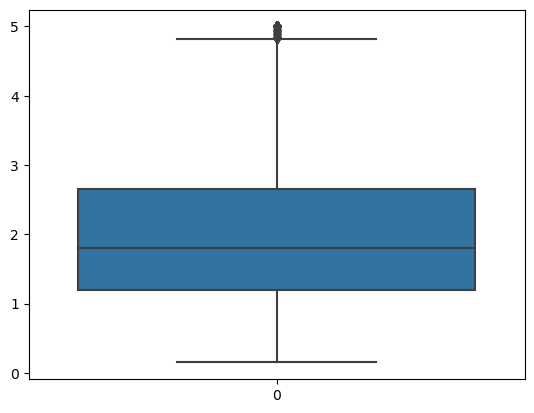

In [27]:
sns.boxplot(df['MedHouseVal']);

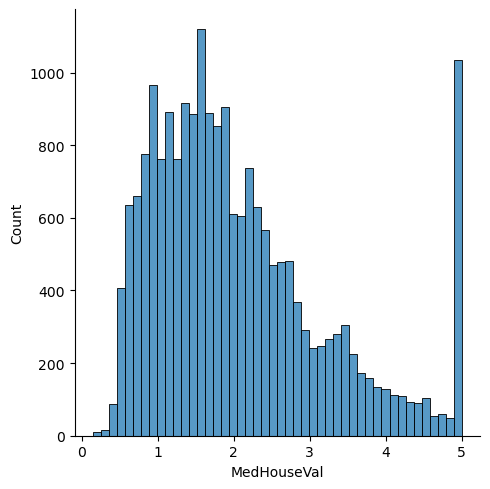

In [28]:
sns.displot(df['MedHouseVal']);

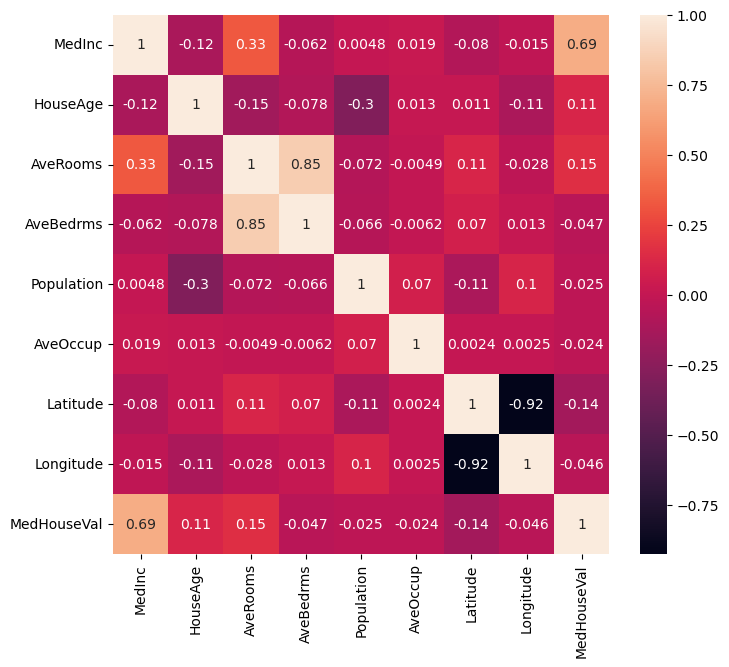

In [29]:
### Cek Korelasi ==> salah satu metode untuk Features Selection
## Pearson
plt.figure(figsize=(8,7))
sns.heatmap(df.corr(), annot=True);

## Feature Selection
- Memilih features yg akan digunakan untuk Training Model (Model Belajar)
- Salah satu cara/metode yg digunakan adalah dg menggunakan Korelasi
- Umumnya menggunakan kolom yg memiliki Korelasi antara atau lebih dari -0.5 s/d 0.5 atau disesuaikan dg kondisi

In [30]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [37]:
df = df.drop(columns=['Population', 'Longitude', 'AveOccup'])

In [38]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Latitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,37.88,4.526
1,8.3014,21.0,6.238137,0.971880,37.86,3.585
2,7.2574,52.0,8.288136,1.073446,37.85,3.521
3,5.6431,52.0,5.817352,1.073059,37.85,3.413
4,3.8462,52.0,6.281853,1.081081,37.85,3.422


In [40]:
## Tentukan Features & Target ==> Soal & Jawaban
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

In [ ]:
## Machine Learning
- Tujuan membuat Machine Learning ==> Bisa memprediksi / Menjawab Soal / Data Baru 
- Data Baru ==> Data yg tidak ada di dataset
- Data Baru ==> Data yg belum dipelajari oleh Model
- Data Baru ==> Data yg sama sekali belum "dilihat" Model, Belum diketahui oleh Model

Model Belajar ==> Model mempelajari Pattern yg ada pada data ==> Training Model
Proses Training Model ==> .fit(X, y) ==> .fit(Features, Target) ==> .fit(Soal, Jawaban)

Soal ==> Kolom Features ==> X
Jawaban ==> Kolom target ==> y

### Evaluation Metrics
- Penilaian sebaik apa model kita
- Membandingkan Jawaban Model dg Kunci jawaban
- Kunci Jawaban ==> Data Aktual yg kita punya (data target)
- Jawaban Model ==> Prediksi dari Model

### Splitting Data
Dataset yg ada kita bagi/split/potong jadi 2
- Data untuk Training/Belajar
- Data untuk Testing/Validasi ==> Data digunakan sebagai Simulasi Data Baru

Data untuk Training/Train data ==> Data yg akan dipelajari Pattern nya oleh Model, Model sudah tau/Melihat Isi dari Features - Target nya.
Data untuk Testing/Test Data ==> Data yg sama sekali belum dilihat - dipelajari oleh Model dan akan diprediksi sebagai Simulasi Data Baru

Dataset (100%)
Akan dipisah menjadi
Data Training 80% ==> Data yg akan dipelajari Model ==> data digunakan untuk belajar ==> Latihan Try Out ==> Model mempelajari Pattern antara Features & Target

Data Testing 20% ==> Data yg akan digunakan untuk Ujian sesungguhnya karena merupakan simulasi Data baru ==> Evaluation Metrics Utama/Penilaian sesungguhnya

Distribusi Train dan Test ==> Cari yg Ideal - Proporsional ==> 70% - 80% untuk Train, 15-30% untuk Test
Jumlah Train + Test = 100%
train 73%
test 27%

## Splitting Dataset

In [41]:
## Tentukan Features & Target ==> Soal & Jawaban
X = df.drop(columns='MedHouseVal') ## Features / Soal
y = df['MedHouseVal'] ## Target / Jawaban

In [42]:
from sklearn.model_selection import train_test_split

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.15, random_state = 999)

In [ ]:
X = Kolom features
y = Kolom target
test_size = .15 ==> Proporsi data yg akan digunakan untuk testing ==> 0.15 ==> 15%
Sisanya akan otomatis digunakan sebagai data training ==> 85%
Ada 2 Opsi yg bisa kita gunakan , kita bisa pake parameter train_size = atau test_size = (Pilih salah satu)
Untuk isinya juga ada 2 opsi, Jumlah langsung baris datanta atau persentase datanya.

Misal
train_size = 500 ==> 500 baris data yg akan digunakan untuk Training
train_size = .75 ==> 75% dari total data (baris data) akan digunakan untuk Training

Proses Splitting data (data untuk train dan test) dilakukan secara random

random_state => angka integer => Digunakan untuk mengunci Randomness, sehingga random yg dilakukan hanya sekali, Nilai random_state bebas asal Integer

In [50]:
X_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Latitude
19273,3.8244,14.0,5.865952,1.068365,38.44
3006,5.1457,5.0,6.395918,1.023469,35.22
16921,3.4333,27.0,3.443080,0.977679,37.57
10074,4.3958,9.0,6.645631,1.237864,39.33
15842,4.6547,52.0,4.567340,1.050505,37.74


In [72]:
X_train.head() ## Data Soal untuk Belajar dan Try Out

,MedInc,HouseAge,AveRooms,AveBedrms,Latitude
19273,3.8244,14.0,5.865952,1.068365,38.44
3006,5.1457,5.0,6.395918,1.023469,35.22
16921,3.4333,27.0,3.443080,0.977679,37.57
10074,4.3958,9.0,6.645631,1.237864,39.33
15842,4.6547,52.0,4.567340,1.050505,37.74


In [73]:
X_test.head() ## Data SOal untuk Simulasi Ujian yg sesungguhnya

,MedInc,HouseAge,AveRooms,AveBedrms,Latitude
2374,3.7261,7.0,5.717532,1.003247,36.70
13150,4.6477,27.0,6.098214,1.241071,36.92
16857,3.1058,32.0,3.936334,1.010977,37.62
6787,2.8062,27.0,5.065445,1.204188,34.09
19109,3.0139,45.0,4.796610,1.067797,38.23


In [74]:
y_train.head() ## Kunci Jawaban untuk Soal Try Out

19273    1.800
3006     1.182
16921    2.900
10074    1.248
15842    3.257
Name: MedHouseVal, dtype: float64

In [75]:
y_test.head() ## Kunci Jawaban untuk Simulasi Ujian sesungguhnya

2374     0.839
13150    2.659
16857    2.530
6787     1.928
19109    1.941
Name: MedHouseVal, dtype: float64

In [76]:
X_train.shape

(17544, 5)

In [77]:
X_test.shape

(3096, 5)

## Machine Learning Modelling

In [78]:
from sklearn.linear_model import LinearRegression

In [79]:
Model = LinearRegression()

In [80]:
Model.fit(X_train, y_train)
## Model Belajar ==> Mencari Pattern dari Soal - Jawaban (Dari Features - Target) Data Training

LinearRegression()

In [81]:
## Quick Evaluation Metrics

In [82]:
Model.score(X_train, y_train) ## Melakukan Penilaian / Evaluation Metrics Train set

0.5344467143124487

In [83]:
Model.score(X_test, y_test) ## Melakukan Penilaian / Eva Metrics Test Set

0.573949399448278

In [ ]:
## Evaluation Metrics
Data Training (data yg dipelajari Model) ==> data yg digunakan untuk Model mencari Pattern => Try Out => Evaluation metrics
Data Testing (Simulasi ujian sesungguhnya/ Data yg sama sekali belum dilihat oleh Model) => Evaluation Metrics

Data yg dipelajari/Dilihat/Diketahui ==> adalah data yg masuk ke dalam .fit(Data)

## Kondisi Penilaian berdasarkan Hasil Evaluation Metrics untuk Data Train dan Data Test
> UnderFitting ==> Dua-dua nya jelek => Nilai Eva Metrics untuk Data training maupun Data testing sama-sama jelek
> Overfitting ==> Nilai Eva metrics untuk Data Training Bagus tapi untuk data testing Jelek ==> Model terlalu Menghafal bukan mencari Pattern ==> Ada perbedaan Signifikan antara nilai eva metrics Training dan Testing
Ada selisih sekitar lebih dari 5 poin
Misal Eva metrics Train ==> 80, EVa metrics Test ==> 72 ==> Ada selisih 8 poin ==> OverFitting => Model terlalu Menghafal
> Fit ==> Nilai Eva metrics untuk Training dan Testing bagus ==> Tidak ada perbedaan signifikan antara nilai eva metrics Training & Testing
Eva metrics Train => 85, Eva Metrics Test => 83
Jika Nilai Eva Metrics Test Lebih Bagus dibanding Eva metrics Train (Meskipun jarang terjadi)


Misal ada Kasus
Model A
Eva metrics Train ==> 93
Eva metrics Test ==> 82

Model B
Eva metrics Train ==> 84
Eva metrics Test ==> 81

Kita akan memilih Model B, Karena lebih Fit dan Stabil
Model A => Overfitting

In [ ]:
## Evaluation Metrics
- Membandingkan "Kunci Jawaban" /Data Target Aktual dengan Jawaban Model - Jawaban Prediksi Model

y_true ==> Data target Aktual ==> Bisa dari y_train atau y_test ==> Tergantung Evaluation Metrics mana yg mau diukur
y_pred ==> Data Target Prediksi ==> Didapat dari Model menjawab Soal/Prediksi dari X_train maupun X_test

In [84]:
Model.predict(X_train) ## Model menjawab Soal yg berasal dari Data Train ==> Try Out

array([1.61312478, 2.12068289, 2.01650556, ..., 2.54055363, 1.35881249,
       1.10105777])

In [85]:
Model.predict(X_test) ## Model men jawab Soal yg berasal dari Data Test ==> Ujian Simulasi data baru 

array([1.47746932, 2.40302912, 1.86102558, ..., 2.06201088, 2.55197607,
       1.06687039])